# Problem 2 - Lasso Penalty Simulation Study

This notebook studies how lasso prediction error changes as the penalty parameter changes. Three
simulation scenarios are used so different penalty strengths can be favored.


In [1]:
### IMPORTS
# Core numerical and dataframe libraries.
import pandas as pd
import numpy as np

# Plotting tools for penalty curves.
import matplotlib.pyplot as plt
plt.style.use('default')

# Lasso model and preprocessing pipeline.
from sklearn.linear_model import Lasso
from sklearn.metrics import mean_squared_error
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler

# Suppress occasional coordinate-descent convergence warnings for extreme alpha values.
import warnings
from sklearn.exceptions import ConvergenceWarning
warnings.filterwarnings("ignore", category=ConvergenceWarning)


In [2]:
### GLOBAL VARS
# Reproducibility seed for all simulation replicates.
RANDOM_SEED = 123
rng = np.random.default_rng(RANDOM_SEED)


## Simulation Setup

Each scenario controls sample size, number of predictors, number of nonzero coefficients, and noise
level. Sparse settings should often benefit from stronger shrinkage, while dense low-noise settings
usually prefer weaker penalties.


In [3]:
# Three scenarios designed to favor different amounts of lasso shrinkage.
SCENARIOS = {
    "sparse_low_noise": {
        "n_train": 80,
        "n_test": 1000,
        "p": 30,
        "n_signal": 5,
        "noise_sd": 0.50,
        "coef_size": 2.0,
    },
    "dense_low_noise": {
        "n_train": 100,
        "n_test": 1000,
        "p": 30,
        "n_signal": 25,
        "noise_sd": 0.50,
        "coef_size": 0.75,
    },
    "sparse_high_noise_many_irrelevant": {
        "n_train": 60,
        "n_test": 1000,
        "p": 100,
        "n_signal": 5,
        "noise_sd": 2.00,
        "coef_size": 2.0,
    },
}

# Alpha is sklearn's lasso penalty parameter. A log grid covers weak to strong shrinkage.
ALPHA_GRID = np.logspace(-3, 1, 30)


In [4]:
def make_lasso_data(n, p, n_signal, noise_sd, coef_size, random_state):
    """Simulate a linear regression data set with sparse or dense true coefficients."""

    # Use a local generator so each replicate is reproducible from its seed.
    local_rng = np.random.default_rng(random_state)

    # Predictors are generated on comparable scales, but we still standardize before lasso.
    X = local_rng.normal(size=(n, p))

    # Build a coefficient vector with n_signal nonzero entries.
    beta = np.zeros(p)
    signal_idx = local_rng.choice(p, size=n_signal, replace=False)
    signs = local_rng.choice([-1.0, 1.0], size=n_signal)
    beta[signal_idx] = signs * coef_size

    # The response is linear signal plus Gaussian noise.
    y = X @ beta + local_rng.normal(scale=noise_sd, size=n)

    return X, y, beta


## Simulation Function

The lasso is fit inside a `StandardScaler` pipeline. Standardization matters because the lasso
penalty is applied directly to coefficient magnitudes; unstandardized variables with larger scales
would be penalized differently from variables with smaller scales.


In [5]:
def run_lasso_simulation(scenarios, alpha_grid, nrep=40, random_state=RANDOM_SEED):
    """Run repeated train/test lasso simulations over scenarios and alpha values."""

    # Master generator creates independent seeds for every scenario and replicate.
    master_rng = np.random.default_rng(random_state)
    rows = []

    for scenario_name, params in scenarios.items():
        for rep in range(nrep):
            # Use separate train and test seeds so test data are independent of training data.
            train_seed = int(master_rng.integers(0, 1_000_000_000))
            test_seed = int(master_rng.integers(0, 1_000_000_000))

            X_train, y_train, beta = make_lasso_data(
                n=params["n_train"],
                p=params["p"],
                n_signal=params["n_signal"],
                noise_sd=params["noise_sd"],
                coef_size=params["coef_size"],
                random_state=train_seed,
            )

            # Reuse the same beta in the test set so train and test share the same truth.
            local_rng = np.random.default_rng(test_seed)
            X_test = local_rng.normal(size=(params["n_test"], params["p"]))
            y_test = X_test @ beta + local_rng.normal(scale=params["noise_sd"], size=params["n_test"])

            for alpha in alpha_grid:
                # StandardScaler is fit only on training data inside the pipeline.
                model = make_pipeline(
                    StandardScaler(),
                    Lasso(alpha=alpha, max_iter=20_000, random_state=random_state),
                )

                model.fit(X_train, y_train)
                preds = model.predict(X_test)
                test_mse = mean_squared_error(y_test, preds)

                rows.append({
                    "scenario": scenario_name,
                    "replicate": rep,
                    "alpha": alpha,
                    "test_mse": test_mse,
                })

    return pd.DataFrame(rows)


In [6]:
# Run the repeated simulation study.
lasso_results = run_lasso_simulation(SCENARIOS, ALPHA_GRID, nrep=40)

# Summarize mean and standard error of test MSE by scenario and penalty value.
lasso_summary = (
    lasso_results
    .groupby(["scenario", "alpha"], as_index=False)
    .agg(
        mean_test_mse=("test_mse", "mean"),
        se_test_mse=("test_mse", lambda x: x.std(ddof=1) / np.sqrt(len(x))),
    )
)

lasso_summary.head()


,scenario,alpha,mean_test_mse,se_test_mse
0,dense_low_noise,0.001000,0.366138,0.006183
1,dense_low_noise,0.001374,0.365805,0.006189
2,dense_low_noise,0.001887,0.365384,0.006200
3,dense_low_noise,0.002593,0.364874,0.006216
4,dense_low_noise,0.003562,0.364298,0.006244


## Best Penalty by Scenario


In [7]:
# Pick the alpha with the smallest mean test MSE in each scenario.
best_alpha_table = (
    lasso_summary
    .sort_values(["scenario", "mean_test_mse"])
    .groupby("scenario", as_index=False)
    .first()
    .loc[:, ["scenario", "alpha", "mean_test_mse"]]
)

best_alpha_table


,scenario,alpha,mean_test_mse
0,dense_low_noise,0.006723,0.363442
1,sparse_high_noise_many_irrelevant,0.303920,6.252778
2,sparse_low_noise,0.045204,0.315647


## Mean Test MSE Versus Penalty


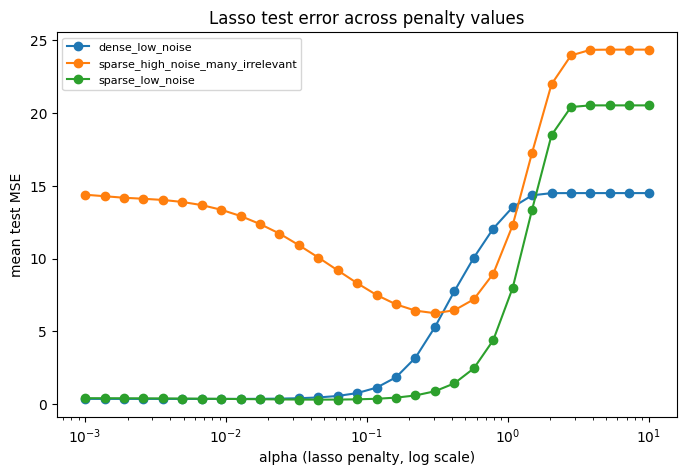

In [8]:
# Plot mean test MSE curves so penalty effects can be compared across scenarios.
fig, ax = plt.subplots(1, 1, figsize=(8, 5))

for scenario_name, group in lasso_summary.groupby("scenario"):
    ordered = group.sort_values("alpha")
    ax.plot(
        ordered["alpha"],
        ordered["mean_test_mse"],
        marker="o",
        linewidth=1.5,
        label=scenario_name,
    )

ax.set_xscale("log")
ax.set_title("Lasso test error across penalty values")
ax.set_xlabel("alpha (lasso penalty, log scale)")
ax.set_ylabel("mean test MSE")
ax.legend(fontsize=8)
plt.show()


## Interpretation

The lasso penalty shrinks coefficients toward zero, and large enough penalties set some coefficients
exactly to zero. This is useful when the true signal is sparse or the data contain many irrelevant
predictors, because shrinkage can reduce variance and remove noise variables. In dense low-noise
settings, strong shrinkage can add too much bias because many predictors truly contribute signal.
The curves above illustrate the bias-variance tradeoff: small penalties can overfit noisy training
patterns, while large penalties can underfit by overshrinking real effects. Standardization is required
because the lasso penalty depends on coefficient size; without scaling, variables measured in larger
units would receive artificially different shrinkage.
